In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pywt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import joblib
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

df = pd.read_csv("health.csv")
df = df.head(14000)

label_columns = ["Labels"]+[f'Labels.{i}' for i in range(1,10)] 
mask = df[label_columns].nunique(axis=1) == 1
filtered_df = df[mask]

filtered_df1 =filtered_df[filtered_df["Labels"]==0]
filtered_df2 =filtered_df[filtered_df["Labels"]==1]
filtered_df3 =filtered_df[filtered_df["Labels"]==2]

min_size = min(len(filtered_df3), len(filtered_df1), len(filtered_df2))

# 3. Downsample the larger classes to the size of the smallest class
filtered_df1 =filtered_df1.sample(n=min_size, random_state=42)
filtered_df2 =filtered_df2.sample(n=min_size, random_state=42)
filtered_df3 =filtered_df3.sample(n=min_size, random_state=42)

label1 = np.zeros(min_size)
label2 = np.zeros(min_size)+1
label3 = np.zeros(min_size)+2
label = np.concatenate([ label1, label2,label3],axis=0)

data = pd.concat([ filtered_df1, filtered_df2,filtered_df3]).reset_index(drop=True)
data["Labels"] = label


In [4]:
df #Orignal Dataset

,0,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,Labels,...,Unnamed: 90,Channel 1.9,Channel 2.9,Channel 3.9,Channel 4.9,Channel 5.9,Channel 6.9,Channel 7.9,Channel 8.9,Labels.9
0,1,0.0,-2.0,-2.0,-3.0,-1.0,-2.0,-1.0,-2.0,0.0,...,NaN,-4.0,-3.0,2.0,0.0,5.0,4.0,0.0,-3.0,0.0
1,2,-1.0,2.0,-3.0,-4.0,-6.0,-4.0,1.0,1.0,0.0,...,NaN,-2.0,-5.0,-1.0,-6.0,-15.0,-4.0,5.0,-7.0,0.0
2,3,2.0,-2.0,0.0,0.0,7.0,1.0,3.0,2.0,0.0,...,NaN,-2.0,-2.0,4.0,1.0,10.0,-3.0,0.0,-5.0,0.0
3,4,0.0,0.0,-1.0,2.0,-2.0,1.0,1.0,-5.0,0.0,...,NaN,-3.0,0.0,0.0,0.0,3.0,8.0,1.0,4.0,0.0
4,5,-1.0,-3.0,0.0,-4.0,0.0,-1.0,-2.0,1.0,0.0,...,NaN,2.0,0.0,-5.0,-1.0,-1.0,1.0,-3.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13995,13996,-1.0,-1.0,0.0,-1.0,-2.0,-5.0,-3.0,0.0,2.0,...,NaN,49.0,35.0,35.0,53.0,4.0,13.0,24.0,30.0,2.0
13996,13997,-2.0,0.0,-2.0,1.0,-1.0,-4.0,0.0,-4.0,2.0,...,NaN,-9.0,-12.0,-1.0,-12.0,-7.0,-1.0,-1.0,-4.0,2.0
13997,13998,0.0,-1.0,-3.0,-3.0,-3.0,15.0,1.0,-2.0,2.0,...,NaN,-19.0,5.0,13.0,-53.0,-25.0,-7.0,-9.0,-15.0,2.0
13998,13999,0.0,0.0,-2.0,4.0,4.0,15.0,10.0,-1.0,2.0,...,NaN,-11.0,-28.0,-5.0,-64.0,5.0,4.0,4.0,-2.0,2.0


# PLOTTING CHANNEL 1 EMG SIGNAL FOR WRIST FLEXION, WRIST EXTENSION AND OPEN HAND

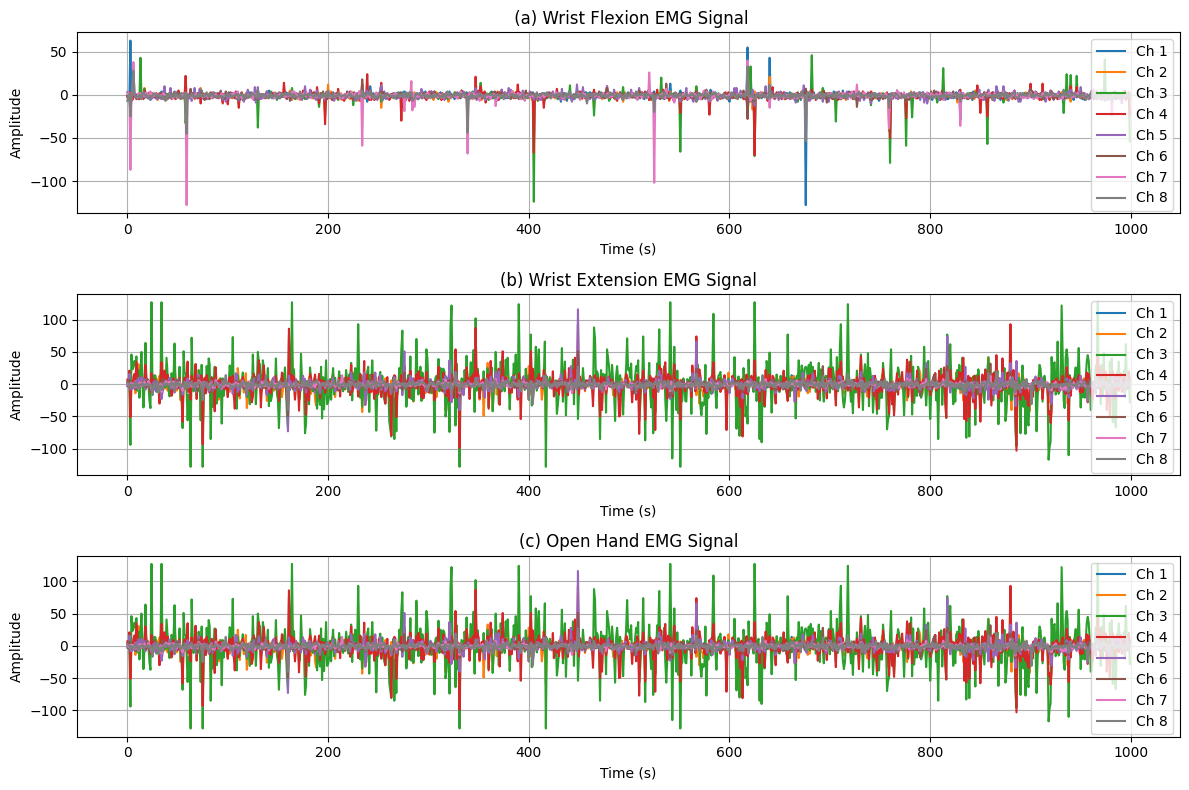

In [5]:
label0 = data[data["Labels"] == 0].head(1000) # Wrist Flexion
label1 = data[data["Labels"] == 1].head(1000) # Wrist Extension
label2 = data[data["Labels"] == 2].head(1000) # Open Hand

# Create time vectors
t0 = np.linspace(0, len(label0["Channel 1"]), len(label0["Channel 1"]), endpoint=False)
t1 = np.linspace(0, len(label1["Channel 1"]), len(label1["Channel 1"]), endpoint=False)
t2 = np.linspace(0, len(label2["Channel 1"]), len(label2["Channel 1"]), endpoint=False)

plt.figure(figsize=(12,8))

plt.subplot(3, 1, 1)
for j in range(1,9):
    plt.plot(t0, label0[f"Channel {j}"], label=f'Ch {j}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f' (a) Wrist Flexion EMG Signal')
plt.grid(True)
plt.legend()
plt.subplot(3, 1, 2)
for j in range(1,9):
    plt.plot(t2, label2[f"Channel {j}"], label=f'Ch {j}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'(b) Wrist Extension EMG Signal')
plt.grid(True)
plt.legend()
plt.subplot(3, 1, 3)
for j in range(1,9):
    plt.plot(t2, label2[f"Channel {j}"], label=f'Ch {j}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'(c) Open Hand EMG Signal')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# Preprocessing The EMG Signal 

In [6]:
# Band-Pass Filtering
def band_pass_filter(data, low_cutoff, high_cutoff, fs, order=4):
    nyquist = 0.5 * fs
    low = low_cutoff / nyquist
    high = high_cutoff / nyquist
    b, a = butter(order, [low, high], btype="band")
    filtered_data = filtfilt(b, a, data)
    rectified_data = np.abs(filtered_data)
    return rectified_data


# Wavelet Denoising
def wavelet_denoising(data, wavelet="db4", level=4):
    coeffs = pywt.wavedec(data, wavelet, level=level)
    threshold = np.sqrt(2 * np.log(len(data)))  # Universal threshold
    coeffs = [pywt.threshold(c, threshold, mode="soft") for c in coeffs]
    denoised_data = pywt.waverec(coeffs, wavelet)
    return denoised_data[: len(data)]  # Ensure the length matches

def Normalize(EMG_Signal):
    return (EMG_Signal - np.min(EMG_Signal)) / (np.max(EMG_Signal) - np.min(EMG_Signal))


def Filtered_Signal(EMG_Signal, fs):

    low_cutoff_freq = 30  # Low cutoff frequency in Hz
    high_cutoff_freq = 300  # High cutoff frequency in Hz
    filtered_data = band_pass_filter(EMG_Signal, low_cutoff_freq, high_cutoff_freq, fs)
    denoised_data = wavelet_denoising(filtered_data)
    Normalize_EMG_Signal = Normalize(denoised_data)
    print("Denoised Completed..!")
    return Normalize_EMG_Signal, denoised_data


In [7]:
channel_cols = [col for col in data.columns if col.startswith('Channel')]
new_data = pd.DataFrame()
denoise = pd.DataFrame()
fs=1000
for channel in channel_cols:
    new_data[channel],denoise[channel]=Filtered_Signal(data[channel], fs)
new_data["Labels"]=data["Labels"]
denoise["Labels"]=data["Labels"]

Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised Completed..!
Denoised C

# Plotting raw vs denoise/filtered signal 

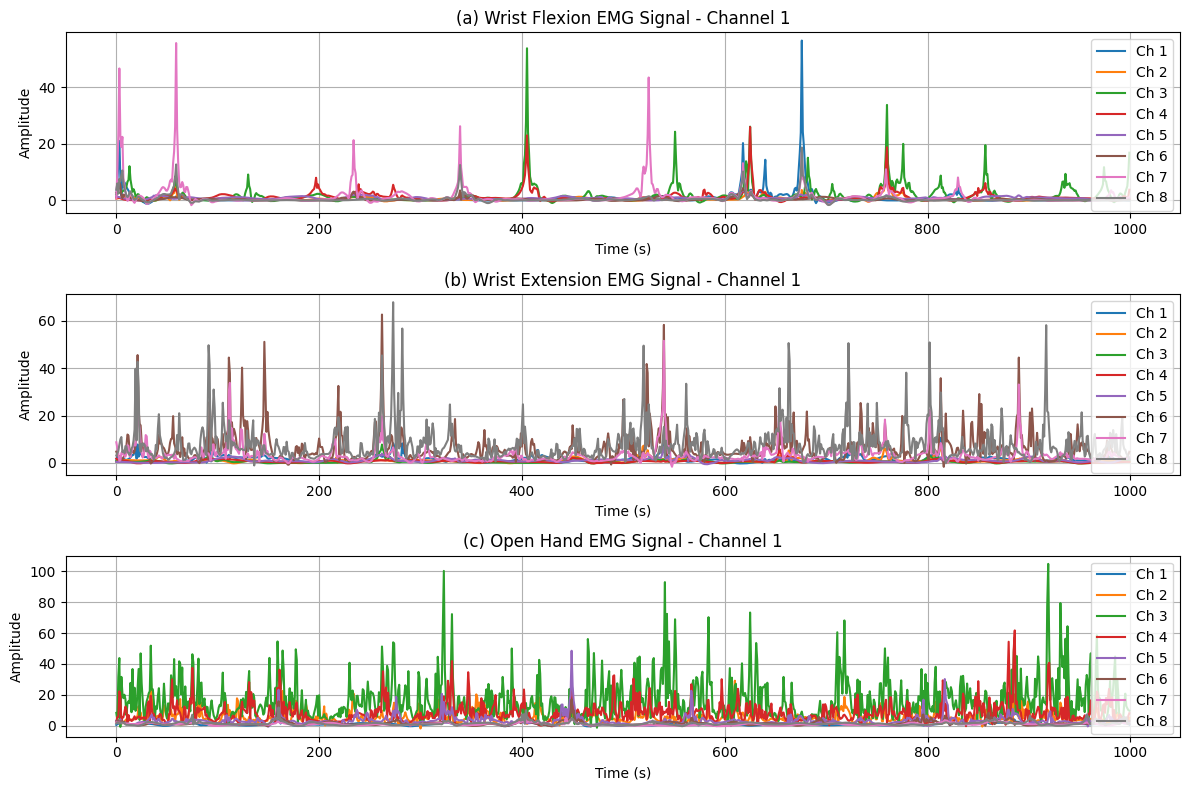

In [8]:
import matplotlib.pyplot as plt

# Filter the data for each label
filtered_l0 = denoise[denoise["Labels"] == 0].head(1000)
filtered_l1 = denoise[denoise["Labels"] == 1].head(1000)
filtered_l2 = denoise[denoise["Labels"] == 2].head(1000)

# Plot the signals
plt.figure(figsize=(12, 8))

# Raw vs Filtered for Wrist Flexion
plt.subplot(3, 1, 1)
for j in range(1,9):
    plt.plot(t0, filtered_l0[f"Channel {j}"], label=f'Ch {j}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('(a) Wrist Flexion EMG Signal - Channel 1')
plt.grid(True)
plt.legend()

# Raw vs Filtered for Wrist Extension
plt.subplot(3, 1, 2)
for j in range(1,9):
#plt.plot(t1, label1["Channel 1"], label='Raw Wrist Extension', alpha=0.5)
    plt.plot(t1, filtered_l1[f"Channel {j}"], label=f'Ch {j}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('(b) Wrist Extension EMG Signal - Channel 1')
plt.grid(True)
plt.legend()

# Raw vs Filtered for Open Hand
plt.subplot(3, 1, 3)
for j in range(1,9):
    plt.plot(t2, filtered_l2[f"Channel {j}"], label=f'Ch {j}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('(c) Open Hand EMG Signal - Channel 1')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# Plotting Normalized EMG signal 

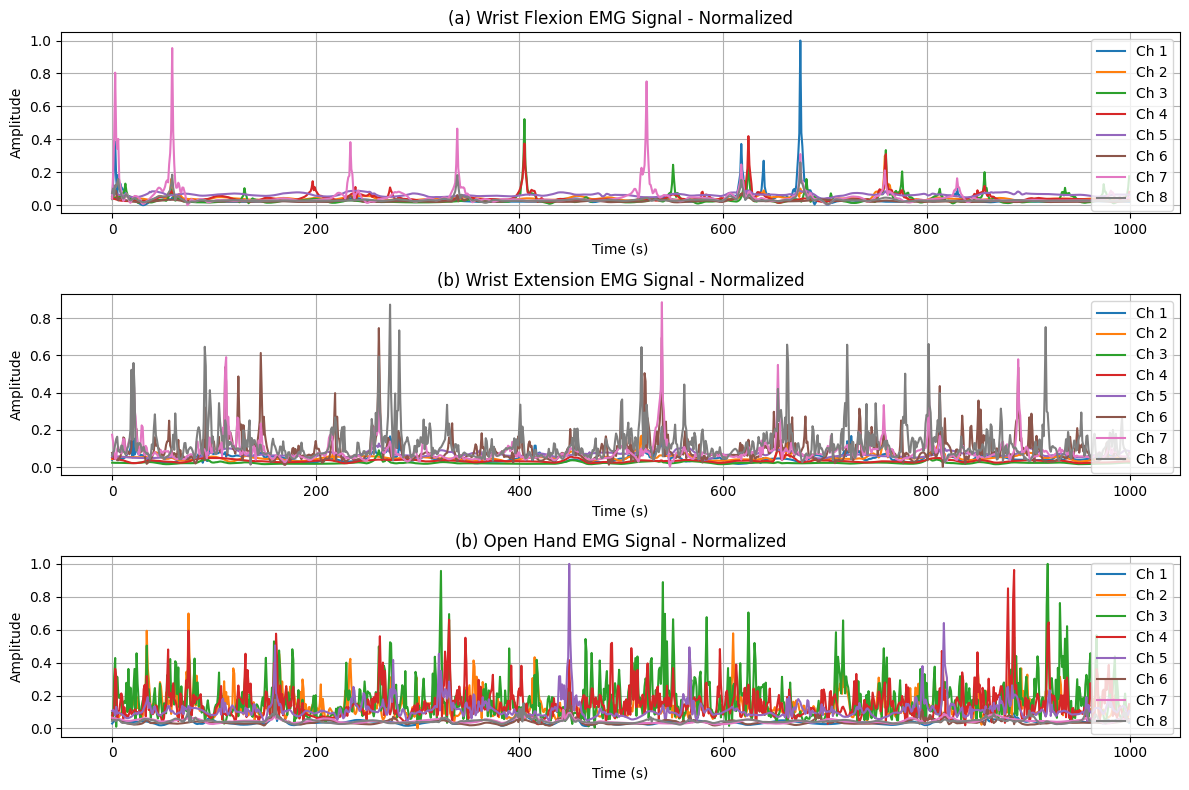

In [9]:

label0 = new_data[new_data["Labels"] == 0].head(1000)
label1 = new_data[new_data["Labels"] == 1].head(1000)
label2 = new_data[new_data["Labels"] == 2].head(1000)

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
for i in range(1,9):
    plt.plot(t0, label0[f"Channel {i}"], label=f'Ch {i}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('(a) Wrist Flexion EMG Signal - Normalized')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
for i in range(1,9):
    plt.plot(t1, label1[f"Channel {i}"], label=f'Ch {i}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('(b) Wrist Extension EMG Signal - Normalized')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
for i in range(1,9):
    plt.plot(t2, label2[f"Channel {i}"], label=f'Ch {i}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('(b) Open Hand EMG Signal - Normalized')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# Concatenates EMG data from multiple columns into a single DataFrame 

In [10]:
# Initialize a dictionary to store concatenated data for each channel
channel_data = {f'Channel {i}': [] for i in range(1, 9)}

# Iterate over the channels
for ch in range(1, 9):
    # Collect columns related to the current channel
    channel_cols = [col for col in new_data.columns if col.startswith(f'Channel {ch}')]

    # Concatenate the data from these columns along the columns axis
    channel_data[f'Channel {ch}'] = np.hstack([new_data[col].values.reshape(-1, 1) for col in channel_cols])

# Create a new DataFrame to store the combined data
combined_data = pd.DataFrame()

# Add the concatenated data for each channel into the new DataFrame
for ch in range(1, 9):
    combined_data[f'Channel {ch}'] = list(channel_data[f'Channel {ch}'])

# Handle the labels separately
labels_cols = [col for col in new_data.columns if 'Labels' in col]
labels = np.hstack([new_data[col].values.reshape(-1, 1) for col in labels_cols])

# Since the labels are duplicated, taking the first column of labels as the representative
combined_data['Labels'] = labels[:, 0]

In [11]:
combined_data 

,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,Labels
0,"[0.03740420833479604, 0.024788945996714638, 0....","[0.04335725433442491, 0.03819132231770112, 0.0...","[0.037372490563590176, 0.04003406299519542, 0....","[0.041989531038208794, 0.08920371067727069, 0....","[0.07589091391453603, 0.04703412452291666, 0.0...","[0.05181345677153096, 0.019450453037918477, 0....","[0.03895184804368516, 0.04522022019880381, 0.1...","[0.07390635318012292, 0.02894382630166354, 0.0...",0.0
1,"[0.13921966039681263, 0.024024314731484385, 0....","[0.04490855480593828, 0.045439544963631825, 0....","[0.040205774748191, 0.0447646069438404, 0.0378...","[0.04045088340567934, 0.09833189518985773, 0.0...","[0.07433922737281595, 0.08105755148491102, 0.0...","[0.05680212275496619, 0.06308430988196073, 0.0...","[0.19038076693379485, 0.049928778272838904, 0....","[0.10145095711757887, 0.030260328011788955, 0....",0.0
2,"[0.2409637425480807, 0.024714378783463747, 0.1...","[0.04664724102508858, 0.07257633299139182, 0.0...","[0.04212135941075391, 0.04700599656999589, 0.0...","[0.03866393160801078, 0.10782598884114881, 0.0...","[0.0725383614173056, 0.11368439386061203, 0.10...","[0.05977839504746799, 0.11217206876686363, 0.0...","[0.41490171074057697, 0.05691284113720772, 0.1...","[0.05639562927633952, 0.041963632894199944, 0....",0.0
3,"[0.38565117972797786, 0.0270391180019259, 0.09...","[0.048585243360752824, 0.1254322145487885, 0.0...","[0.04271566910989242, 0.045700719507516495, 0....","[0.036612576390475556, 0.11635477944836459, 0....","[0.07047178564602292, 0.14645305167817718, 0.0...","[0.09305364778977968, 0.1831674973807173, 0.06...","[0.8049258610542793, 0.0654188486261813, 0.141...","[0.12149550939074225, 0.06444668694256278, 0.0...",0.0
4,"[0.16385711848322412, 0.029810500950561036, 0....","[0.05062601944479216, 0.10462497972014598, 0.0...","[0.043694565013822365, 0.04433685998455742, 0....","[0.034431175207634064, 0.15953969992787323, 0....","[0.06827822570992605, 0.17356971716056502, 0.0...","[0.08368054086618748, 0.008286982101455715, 0....","[0.40996555404288615, 0.08471391329258074, 0.1...","[0.11006966950464867, 0.08061235847588813, 0.0...",0.0
...,...,...,...,...,...,...,...,...,...
10999,"[0.026187616336833384, 0.05038984274763112, 0....","[0.16377520316026073, 0.06796572315171423, 0.0...","[0.15789620912335284, 0.07841044407069278, 0.3...","[0.08228352581265931, 0.20152028004938083, 0.1...","[0.09854319308448763, 0.22085926463847977, 0.1...","[0.03873392815097718, 0.572181109602807, 0.195...","[0.030350818615182143, 0.20514053873551616, 0....","[0.035070743639856274, 0.14778635869707527, 0....",2.0
11000,"[0.024638926849532033, 0.04584731796057926, 0....","[0.24068243076799928, 0.06604289305877531, 0.0...","[0.1373187117270563, 0.04365520340000801, 0.45...","[0.16227138517421147, 0.3274269303321323, 0.15...","[0.10782554248996934, 0.534533630922629, 0.082...","[0.0416672142076295, 0.3168869383226001, 0.190...","[0.028912191666592556, 0.19318988811305413, 0....","[0.03413984586891273, 0.11913650048653708, 0.0...",2.0
11001,"[0.023630566090168975, 0.03746906167381263, 0....","[0.2413442249432783, 0.08759999716791553, 0.07...","[0.28325400549076496, 0.140249243871752, 0.560...","[0.14048000077122463, 0.6322337897452885, 0.13...","[0.12320714943681813, 1.0, 0.12735907262891916...","[0.04547130917718963, 0.6745565999161258, 0.18...","[0.02794470700198696, 0.14026615307202298, 0.2...","[0.033271133361001834, 0.0716581335488357, 0.0...",2.0
11002,"[0.0227074128124896, 0.03230714461459564, 0.08...","[0.154035199446956, 0.0806693598158117, 0.0691...","[0.34949883230121487, 0.1172718125360382, 0.45...","[0.03840126419554355, 0.5240496023242128, 0.07...","[0.11889987965315461, 0.8694064905684029, 0.17...","[0.04315421453998346, 1.0, 0.18012194486250005...","[0.027188269069574073, 0.1633083122069305, 0.4...","[0.032624769030851965, 0.04293367922698099, 0....",2.0


# functions to extract various time-domain and frequency-domain features from EMG signals

In [42]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define the feature extraction functions
def calculate_IEMG(signal):
    return np.sum(np.abs(signal))

def calculate_MAV(signal):
    return np.mean(np.abs(signal))

def calculate_MAV1(signal):
    return np.mean(np.abs(signal - np.mean(signal)))

def calculate_MAV2(signal):
    return np.mean(np.abs(signal - np.mean(signal)) ** 2)

def calculate_SSI(signal):
    return np.sum(signal**2)

def calculate_VAR(signal):
    return np.var(signal)

def calculate_RMS(signal):
    return np.sqrt(np.mean(signal**2))

def calculate_WL(signal):
    return np.sum(np.abs(np.diff(signal)))

def calculate_H1(signal):
    return np.var(signal)

def calculate_SD(signal):
    return np.std(signal)

def calculate_MAD(signal):
    return np.mean(np.abs(signal - np.mean(signal)))

def spectrum(signal, fs):
    m = len(signal)
    n = next_power_of_2(m)
    y = np.fft.fft(signal, n)
    yh = y[0 : int(n / 2 - 1)]
    fh = (fs / n) * np.arange(0, n / 2 - 1, 1)
    power = np.real(yh * np.conj(yh) / n)
    return fh, power

def next_power_of_2(x):
    return 1 if x == 0 else 2 ** (x - 1).bit_length()

def calculate_mean_frequency(f, psd):
    return np.average(f, weights=psd) / np.sum(psd)

def calculate_median_frequency(f, psd):
    cumulative_sum = np.cumsum(psd)
    return f[np.searchsorted(cumulative_sum, cumulative_sum[-1] / 2)]

def calculate_power_bandwidth(f, psd):
    total_power = np.sum(psd)
    cumulative_power = np.cumsum(psd)
    lower_index = np.argmax(cumulative_power >= total_power * 0.025)
    upper_index = np.argmax(cumulative_power >= total_power * 0.975)
    return f[upper_index] - f[lower_index]

def calculate_THD(f, psd):
    fundamental_freq_index = np.argmax(psd)
    fundamental_power = psd[fundamental_freq_index]
    harmonic_indices = [
        2 * fundamental_freq_index,
        3 * fundamental_freq_index,
        4 * fundamental_freq_index,
    ]
    harmonic_power = np.sum([psd[i] for i in harmonic_indices if i < len(psd)])
    return harmonic_power / fundamental_power

def extract_features(signal):
    # Time-domain features
    time_domain_features = [
        calculate_IEMG(signal),
        calculate_MAV(signal),
        calculate_MAV1(signal),
        calculate_MAV2(signal),
        calculate_SSI(signal),
        calculate_VAR(signal),
        calculate_RMS(signal),
        calculate_WL(signal),
        calculate_H1(signal),
        calculate_SD(signal),
        calculate_MAD(signal),
    ]
    
    # Frequency-domain features
    fs = 1000  # Sampling frequency
    fh, psd = spectrum(signal, fs)
    freq_domain_features = [
        calculate_mean_frequency(fh, psd),
        calculate_median_frequency(fh, psd),
        calculate_power_bandwidth(fh, psd),
        calculate_THD(fh, psd),
    ]
    
    # Combine time and frequency domain features
    features = time_domain_features + freq_domain_features
    return features


In [28]:
# Define the feature names
feature_names = [
    'IEMG', 'MAV', 'MAV1', 'MAV2', 'SSI', 'VAR', 'RMS', 'WL', 'H1', 'SD', 'MAD',
    'Mean_Frequency', 'Median_Frequency', 'Power_Bandwidth', 'THD'
]

# Extract features for each channel and combine them for each sample
features_list = []
labels_list = combined_data["Labels"]

for i in range(len(combined_data)):
    combined_features = []
    for j in range(1, 9):
        signal = combined_data.iloc[i][f"Channel {j}"]
        features = extract_features(signal)
        combined_features.extend(features)
    features_list.append(combined_features)

# Create DataFrame for features
columns = [f"{feature}_Ch{j}" for j in range(1, 9) for feature in feature_names]
features_df = pd.DataFrame(features_list, columns=columns)

# Add labels to the features DataFrame
features_df["Labels"] = labels_list

# Display the combined_df to verify
print(features_df.head())


   IEMG_Ch1   MAV_Ch1  MAV1_Ch1  MAV2_Ch1   SSI_Ch1   VAR_Ch1   RMS_Ch1  \
0  0.458177  0.045818  0.020994  0.000869  0.029684  0.000869  0.054483   
1  1.112332  0.111233  0.080787  0.015644  0.280166  0.015644  0.167381   
2  1.378165  0.137817  0.104396  0.020074  0.390674  0.020074  0.197655   
3  1.444502  0.144450  0.120053  0.018121  0.389869  0.018121  0.197451   
4  1.108784  0.110878  0.072507  0.008466  0.207603  0.008466  0.144084   

     WL_Ch1    H1_Ch1    SD_Ch1  ...   RMS_Ch8    WL_Ch8    H1_Ch8    SD_Ch8  \
0  0.284226  0.000869  0.029481  ...  0.046436  0.188151  0.000298  0.017256   
1  1.133460  0.015644  0.125075  ...  0.055351  0.225511  0.000526  0.022931   
2  1.337275  0.020074  0.141683  ...  0.052136  0.174483  0.000275  0.016592   
3  1.137032  0.018121  0.134614  ...  0.064676  0.221782  0.000745  0.027291   
4  0.899003  0.008466  0.092012  ...  0.065171  0.199186  0.000636  0.025227   

    MAD_Ch8  Mean_Frequency_Ch8  Median_Frequency_Ch8  Power_Bandwid

In [29]:
combined_data.shape ,features_df.shape

((11004, 9), (11004, 121))

# SVM Model 

Feature: IEMG, Accuracy: 89.87%
Feature: MAV, Accuracy: 89.87%
Feature: MAV1, Accuracy: 80.96%
Feature: MAV2, Accuracy: 76.33%
Feature: SSI, Accuracy: 83.10%
Feature: VAR, Accuracy: 76.33%
Feature: RMS, Accuracy: 83.92%
Feature: WL, Accuracy: 81.19%
Feature: H1, Accuracy: 76.33%
Feature: SD, Accuracy: 77.96%
Feature: MAD, Accuracy: 80.96%
Feature: Mean_Frequency, Accuracy: 94.87%
Feature: Median_Frequency, Accuracy: 64.61%
Feature: Power_Bandwidth, Accuracy: 69.74%
Feature: THD, Accuracy: 33.30%

Best Model Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       733
         1.0       0.93      0.92      0.92       734
         2.0       0.92      0.93      0.92       734

    accuracy                           0.95      2201
   macro avg       0.95      0.95      0.95      2201
weighted avg       0.95      0.95      0.95      2201



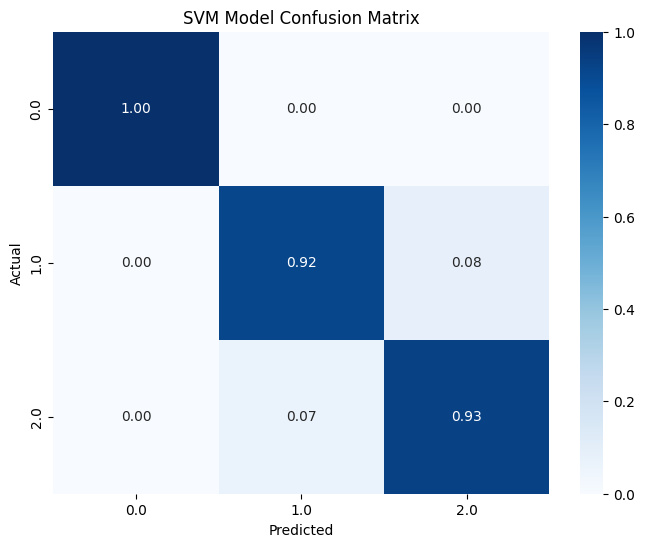

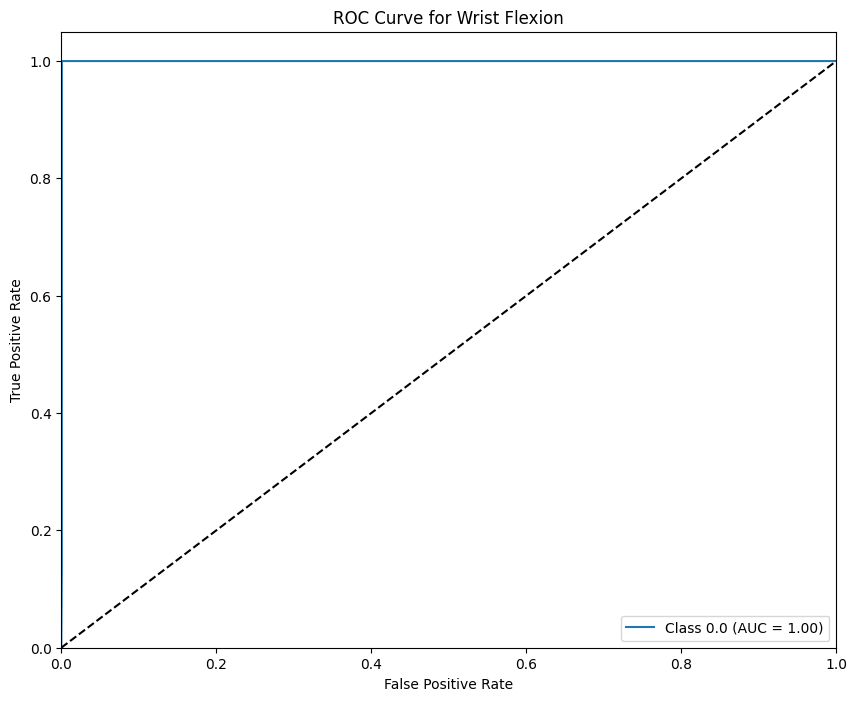

Class 0.0: AUC = 1.00


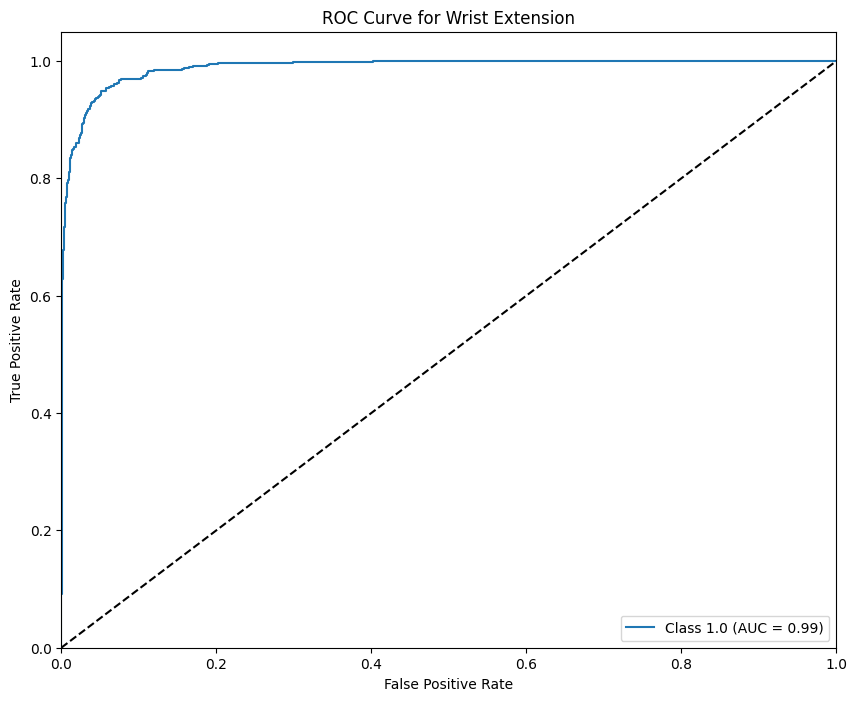

Class 1.0: AUC = 0.99


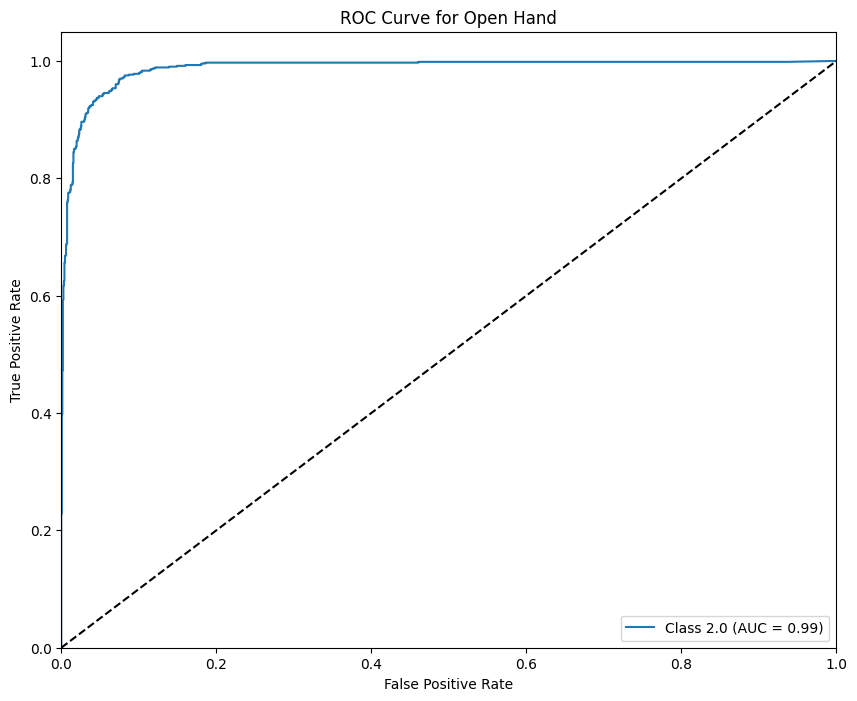

Class 2.0: AUC = 0.99

Top 5 Features with Highest Accuracies:
Feature: Mean_Frequency, Accuracy: 94.87%
Feature: IEMG, Accuracy: 89.87%
Feature: MAV, Accuracy: 89.87%
Feature: RMS, Accuracy: 83.92%
Feature: SSI, Accuracy: 83.10%


In [48]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

best_accuracy = 0
best_model = None
best_scaler = None
best_feature = None

# Dictionary to store accuracies
accuracies = {}

# Iterate over each feature
for feature in feature_names:
    selected_columns = [f"{feature}_Ch{j}" for j in range(1, 9)]
    selected_features_df = features_df[selected_columns].copy()
    selected_features_df["Labels"] = features_df["Labels"].values

    X = selected_features_df.drop("Labels", axis=1)
    y = selected_features_df["Labels"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Create and fit the SVC model
    svm = SVC(kernel='linear', probability=True, random_state=42)
    svm.fit(X_train, y_train)

    y_pred = svm.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    accuracies[feature] = accuracy
    print(f"Feature: {feature}, Accuracy: {accuracy * 100:.2f}%")

    # Update best model if current model is better
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_feature = feature
        best_model = svm
        best_scaler = scaler

# Save the best model and its scaler
if best_model is not None:
    joblib.dump(best_model, 'best_svm_model.joblib')
    joblib.dump(best_scaler, 'best_svm_scaler.joblib')

# Print classification report and confusion matrix for the best model
if best_model is not None:
    print("\nBest Model Classification Report:")
    
    # Select data for the best feature
    selected_columns = [f"{best_feature}_Ch{j}" for j in range(1, 9)]
    best_features_df = features_df[selected_columns].copy()
    best_features_df["Labels"] = features_df["Labels"].values

    X = best_features_df.drop("Labels", axis=1)
    y = best_features_df["Labels"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    X_train_transformed = best_scaler.transform(X_train)
    X_test_transformed = best_scaler.transform(X_test)

    y_pred_best = best_model.predict(X_test_transformed)
    
    print(classification_report(y_test, y_pred_best))

    # Confusion Matrix
    conf_matrix = confusion_matrix(y_test, y_pred_best)
    
    # Normalize the confusion matrix
    row_sums = conf_matrix.sum(axis=1, keepdims=True)
    conf_matrix_normalized = conf_matrix / row_sums

    # Plot normalized confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=y.unique(), yticklabels=y.unique())
    plt.title(f'SVM Model Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # ROC Curve and AUC Calculation
    y_test_binarized = label_binarize(y_test, classes=y.unique())
    y_pred_prob = best_model.predict_proba(X_test_transformed)

    classes = y.unique()
    labels = ["Wrist Flexion", "Wrist Extension", "Open Hand"]
    for i, class_label in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_prob[:, i])
        roc_auc = auc(fpr, tpr)
        
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve for {labels[int(class_label)]}')
        plt.legend(loc="lower right")
        plt.show()

        # Print AUC for each class
        print(f"Class {class_label}: AUC = {roc_auc:.2f}")

# Sort features by accuracy
sorted_features = sorted(accuracies.items(), key=lambda item: item[1], reverse=True)

# Select the top 5 features with the highest accuracies
top_5_features = sorted_features[:5]

print("\nTop 5 Features with Highest Accuracies:")
for feature, accuracy in top_5_features:
    print(f"Feature: {feature}, Accuracy: {accuracy * 100:.2f}%")


# Random Forest Model

Feature: IEMG, Accuracy: 90.50%
Feature: MAV, Accuracy: 90.50%
Feature: MAV1, Accuracy: 82.74%
Feature: MAV2, Accuracy: 81.28%
Feature: SSI, Accuracy: 85.78%
Feature: VAR, Accuracy: 81.28%
Feature: RMS, Accuracy: 85.92%
Feature: WL, Accuracy: 83.10%
Feature: H1, Accuracy: 81.28%
Feature: SD, Accuracy: 81.33%
Feature: MAD, Accuracy: 82.74%
Feature: Mean_Frequency, Accuracy: 94.68%
Feature: Median_Frequency, Accuracy: 64.61%
Feature: Power_Bandwidth, Accuracy: 68.61%
Feature: THD, Accuracy: 33.35%

Best Model Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       733
         1.0       0.92      0.92      0.92       734
         2.0       0.92      0.92      0.92       734

    accuracy                           0.95      2201
   macro avg       0.95      0.95      0.95      2201
weighted avg       0.95      0.95      0.95      2201



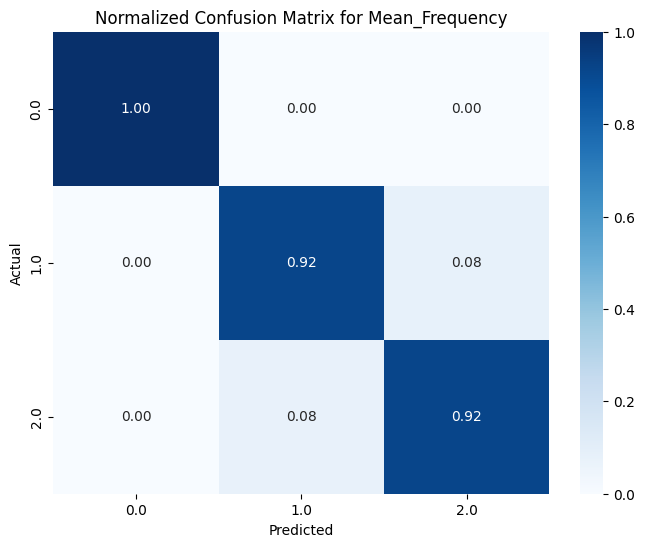

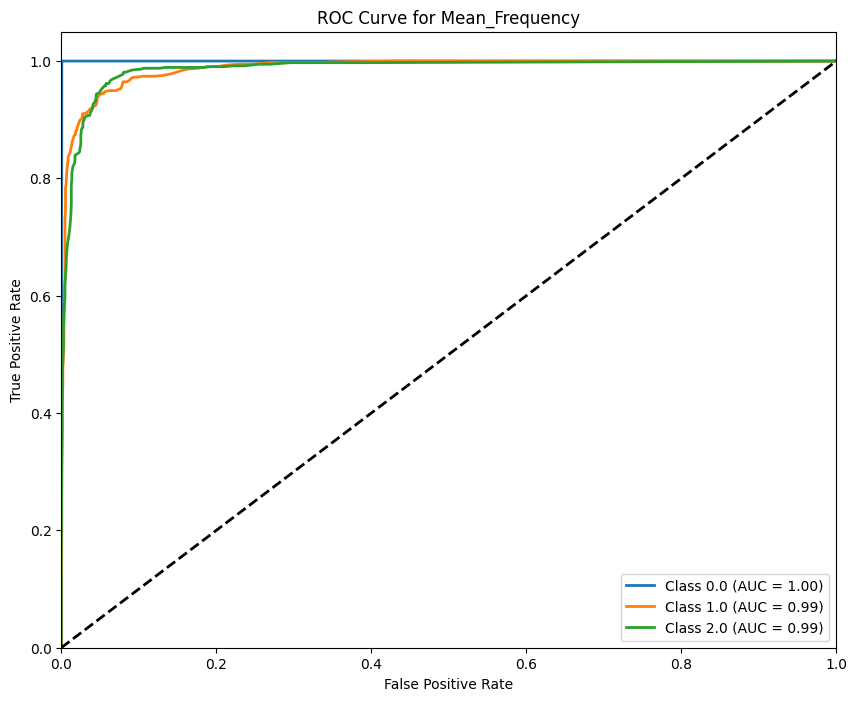


Top 5 Features with Highest Accuracies:
Feature: Mean_Frequency, Accuracy: 94.68%
Feature: IEMG, Accuracy: 90.50%
Feature: MAV, Accuracy: 90.50%
Feature: RMS, Accuracy: 85.92%
Feature: SSI, Accuracy: 85.78%


In [43]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

best_accuracy = 0
best_model = None
best_scaler = None
best_feature = None

# Dictionary to store accuracies
accuracies = {}

# Iterate over each feature
for feature in feature_names:
    selected_columns = [f"{feature}_Ch{j}" for j in range(1, 9)]
    selected_features_df = features_df[selected_columns].copy()
    selected_features_df["Labels"] = features_df["Labels"].values

    X = selected_features_df.drop("Labels", axis=1)
    y = selected_features_df["Labels"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Create and fit the Random Forest model
    rfc = RandomForestClassifier(n_estimators=100, random_state=42)
    rfc.fit(X_train, y_train)

    y_pred = rfc.predict(X_test)
    y_pred_proba = rfc.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    accuracies[feature] = accuracy
    print(f"Feature: {feature}, Accuracy: {accuracy * 100:.2f}%")

    # Update best model if current model is better
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_feature = feature
        best_model = rfc
        best_scaler = scaler

# Save the best model and its scaler
if best_model is not None:
    joblib.dump(best_model, 'best_rf_model.joblib')
    joblib.dump(best_scaler, 'best_rf_scaler.joblib')

# Print classification report and confusion matrix for the best model
if best_model is not None:
    print("\nBest Model Classification Report:")
    
    # Select data for the best feature
    selected_columns = [f"{best_feature}_Ch{j}" for j in range(1, 9)]
    best_features_df = features_df[selected_columns].copy()
    best_features_df["Labels"] = features_df["Labels"].values

    X = best_features_df.drop("Labels", axis=1)
    y = best_features_df["Labels"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    X_train_transformed = best_scaler.transform(X_train)
    X_test_transformed = best_scaler.transform(X_test)

    y_pred_best = best_model.predict(X_test_transformed)
    y_pred_proba_best = best_model.predict_proba(X_test_transformed)
    
    print(classification_report(y_test, y_pred_best))

    # Confusion Matrix
    conf_matrix = confusion_matrix(y_test, y_pred_best)
    
    # Normalize the confusion matrix
    row_sums = conf_matrix.sum(axis=1, keepdims=True)
    conf_matrix_normalized = conf_matrix / row_sums

    # Plot normalized confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=y.unique(), yticklabels=y.unique())
    plt.title(f'Normalized Confusion Matrix for {best_feature}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Plot ROC Curve
    plt.figure(figsize=(10, 8))
    for i, class_label in enumerate(y.unique()):
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best[:, i], pos_label=class_label)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'Class {class_label} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {best_feature}')
    plt.legend(loc='lower right')
    plt.show()

# Sort features by accuracy
sorted_features = sorted(accuracies.items(), key=lambda item: item[1], reverse=True)

# Select the top 5 features with the highest accuracies
top_5_features = sorted_features[:5]

print("\nTop 5 Features with Highest Accuracies:")
for feature, accuracy in top_5_features:
    print(f"Feature: {feature}, Accuracy: {accuracy * 100:.2f}%")


# Using Linear Discriminant Analysis Model

Feature: IEMG, Accuracy: 89.82%
Feature: MAV, Accuracy: 89.82%
Feature: MAV1, Accuracy: 80.01%
Feature: MAV2, Accuracy: 70.97%
Feature: SSI, Accuracy: 80.24%
Feature: VAR, Accuracy: 70.97%
Feature: RMS, Accuracy: 83.42%
Feature: WL, Accuracy: 80.05%
Feature: H1, Accuracy: 70.97%
Feature: SD, Accuracy: 76.69%
Feature: MAD, Accuracy: 80.01%
Feature: Mean_Frequency, Accuracy: 92.91%
Feature: Median_Frequency, Accuracy: 63.29%
Feature: Power_Bandwidth, Accuracy: 67.38%
Feature: THD, Accuracy: 34.12%

Best Model Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99       733
         1.0       0.93      0.86      0.89       734
         2.0       0.87      0.95      0.91       734

    accuracy                           0.93      2201
   macro avg       0.93      0.93      0.93      2201
weighted avg       0.93      0.93      0.93      2201



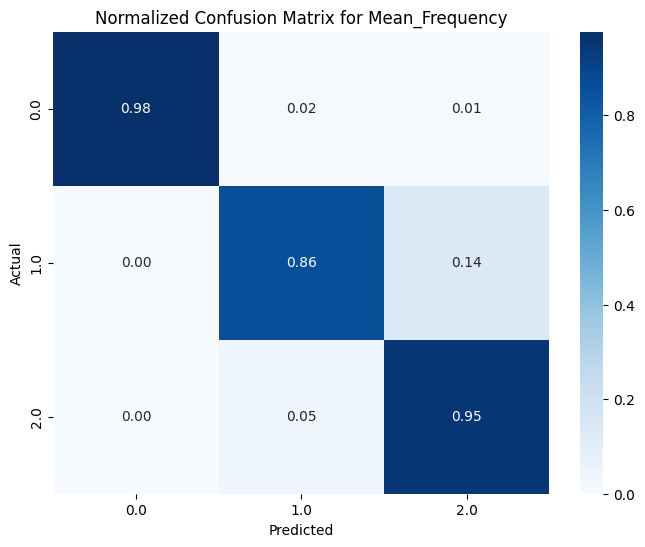


Top 5 Features with Highest Accuracies:
Feature: Mean_Frequency, Accuracy: 92.91%
Feature: IEMG, Accuracy: 89.82%
Feature: MAV, Accuracy: 89.82%
Feature: RMS, Accuracy: 83.42%
Feature: SSI, Accuracy: 80.24%


In [40]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

best_accuracy = 0
best_model = None
best_scaler = None
best_feature = None

# Dictionary to store accuracies
accuracies = {}

# Iterate over each feature
for feature in feature_names:
    selected_columns = [f"{feature}_Ch{j}" for j in range(1, 9)]
    selected_features_df = features_df[selected_columns].copy()
    selected_features_df["Labels"] = features_df["Labels"].values

    X = selected_features_df.drop("Labels", axis=1)
    y = selected_features_df["Labels"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Create and fit the LDA model
    lda = LDA()
    lda.fit(X_train, y_train)

    y_pred = lda.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    accuracies[feature] = accuracy
    print(f"Feature: {feature}, Accuracy: {accuracy * 100:.2f}%")

    # Update best model if current model is better
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_feature = feature
        best_model = lda
        best_scaler = scaler

# Save the best model and its scaler
if best_model is not None:
    joblib.dump(best_model, 'best_lda_model.joblib')
    joblib.dump(best_scaler, 'best_lda_scaler.joblib')

# Print classification report and confusion matrix for the best model
if best_model is not None:
    print("\nBest Model Classification Report:")
    
    # Select data for the best feature
    selected_columns = [f"{best_feature}_Ch{j}" for j in range(1, 9)]
    best_features_df = features_df[selected_columns].copy()
    best_features_df["Labels"] = features_df["Labels"].values

    X = best_features_df.drop("Labels", axis=1)
    y = best_features_df["Labels"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    X_train_transformed = best_scaler.transform(X_train)
    X_test_transformed = best_scaler.transform(X_test)

    y_pred_best = best_model.predict(X_test_transformed)
    
    print(classification_report(y_test, y_pred_best))

    # Confusion Matrix
    conf_matrix = confusion_matrix(y_test, y_pred_best)
    
    # Normalize the confusion matrix
    row_sums = conf_matrix.sum(axis=1, keepdims=True)
    conf_matrix_normalized = conf_matrix / row_sums

    # Plot normalized confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=y.unique(), yticklabels=y.unique())
    plt.title(f'Normalized Confusion Matrix for {best_feature}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


# Sort features by accuracy
sorted_features = sorted(accuracies.items(), key=lambda item: item[1], reverse=True)

# Select the top 5 features with the highest accuracies
top_5_features = sorted_features[:5]

print("\nTop 5 Features with Highest Accuracies:")
for feature, accuracy in top_5_features:
    print(f"Feature: {feature}, Accuracy: {accuracy * 100:.2f}%")


# USing KNeighbors Classifier Model

Feature: IEMG, Accuracy: 89.23%
Feature: MAV, Accuracy: 89.23%
Feature: MAV1, Accuracy: 81.14%
Feature: MAV2, Accuracy: 77.33%
Feature: SSI, Accuracy: 83.42%
Feature: VAR, Accuracy: 77.33%
Feature: RMS, Accuracy: 83.73%
Feature: WL, Accuracy: 79.96%
Feature: H1, Accuracy: 77.33%
Feature: SD, Accuracy: 79.78%
Feature: MAD, Accuracy: 81.14%
Feature: Mean_Frequency, Accuracy: 93.64%
Feature: Median_Frequency, Accuracy: 63.52%
Feature: Power_Bandwidth, Accuracy: 66.97%
Feature: THD, Accuracy: 31.49%

Best Model Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       733
         1.0       0.90      0.91      0.91       734
         2.0       0.91      0.90      0.90       734

    accuracy                           0.94      2201
   macro avg       0.94      0.94      0.94      2201
weighted avg       0.94      0.94      0.94      2201



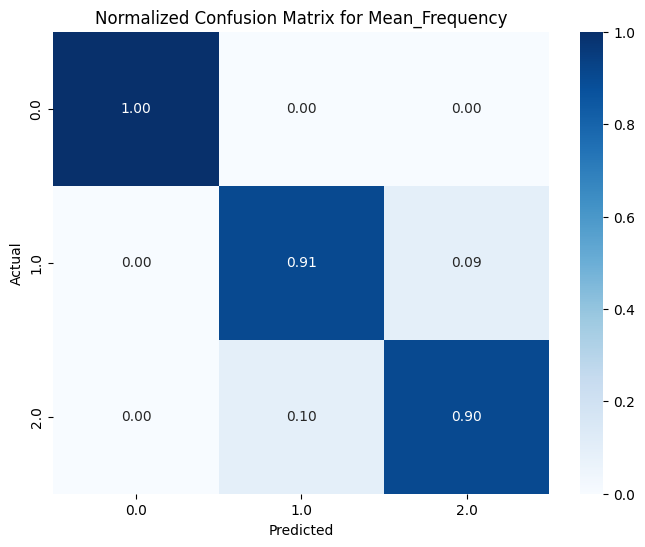


Top 5 Features with Highest Accuracies:
Feature: Mean_Frequency, Accuracy: 93.64%
Feature: IEMG, Accuracy: 89.23%
Feature: MAV, Accuracy: 89.23%
Feature: RMS, Accuracy: 83.73%
Feature: SSI, Accuracy: 83.42%


In [41]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

best_accuracy = 0
best_model = None
best_scaler = None
best_feature = None

# Dictionary to store accuracies
accuracies = {}

# Iterate over each feature
for feature in feature_names:
    selected_columns = [f"{feature}_Ch{j}" for j in range(1, 9)]
    selected_features_df = features_df[selected_columns].copy()
    selected_features_df["Labels"] = features_df["Labels"].values

    X = selected_features_df.drop("Labels", axis=1)
    y = selected_features_df["Labels"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Create and fit the KNN model
    knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust the number of neighbors as needed
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    accuracies[feature] = accuracy
    print(f"Feature: {feature}, Accuracy: {accuracy * 100:.2f}%")

    # Update best model if current model is better
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_feature = feature
        best_model = knn
        best_scaler = scaler

# Save the best model and its scaler
if best_model is not None:
    joblib.dump(best_model, 'best_knn_model.joblib')
    joblib.dump(best_scaler, 'best_knn_scaler.joblib')

# Print classification report and confusion matrix for the best model
if best_model is not None:
    print("\nBest Model Classification Report:")
    
    # Select data for the best feature
    selected_columns = [f"{best_feature}_Ch{j}" for j in range(1, 9)]
    best_features_df = features_df[selected_columns].copy()
    best_features_df["Labels"] = features_df["Labels"].values

    X = best_features_df.drop("Labels", axis=1)
    y = best_features_df["Labels"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    X_train_transformed = best_scaler.transform(X_train)
    X_test_transformed = best_scaler.transform(X_test)

    y_pred_best = best_model.predict(X_test_transformed)
    
    print(classification_report(y_test, y_pred_best))

    # Confusion Matrix
    conf_matrix = confusion_matrix(y_test, y_pred_best)
    
    # Normalize the confusion matrix
    row_sums = conf_matrix.sum(axis=1, keepdims=True)
    conf_matrix_normalized = conf_matrix / row_sums

    # Plot normalized confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=y.unique(), yticklabels=y.unique())
    plt.title(f'Normalized Confusion Matrix for {best_feature}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Sort features by accuracy
sorted_features = sorted(accuracies.items(), key=lambda item: item[1], reverse=True)

# Select the top 5 features with the highest accuracies
top_5_features = sorted_features[:5]

print("\nTop 5 Features with Highest Accuracies:")
for feature, accuracy in top_5_features:
    print(f"Feature: {feature}, Accuracy: {accuracy * 100:.2f}%")
